In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import sys
import random
import plotting
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.io import savemat
import torch
import torch.nn.functional as F
import time
import itertools
from itertools import cycle
import scipy
from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

Ts = 0.1
ld = 40
N = 40
l_layer = 1
l_neuron_branch = 40*2
l_neuron_trunk  = 5*2

(501, 4)


Text(0.5, 0, 'Time [s]')

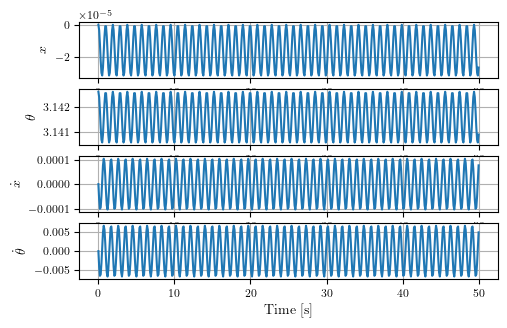

In [2]:
# define pendulum on a cart 
def penulum_cart(t, y, M=2.4, m=0.23, l = 0.18, g=9.81, u=0):
    x, theta, dx, dtheta = y

    s = np.sin(theta)
    c = np.cos(theta)

    ddx = (4*u - 3*m*g*s*c + 4*m*l*s*dtheta**2)/(4*(m+M)-3*m*c**2)
    ddtheta = ((M+m)*3*g*s-3*u*c - 3*l*m*s*c*dtheta**2)/(4*l*(m+M)  - 3*l*m*c**2)

    return [dx, dtheta, ddx, ddtheta]


y0 = [0,np.pi+0.001,0,0]
x = [y0]
t_vec = [0]

for k in range(500):
    # print(k)
    sol = solve_ivp(lambda t, y: penulum_cart(t, y),[0, Ts], y0, method='RK45')
    y0 = sol.y[:, -1]
    x.append(y0)  # store state
    t_vec.append((k+1) * Ts)  # store time

x = np.array(x)
print(x.shape)

plt.subplot(4,1,1)
plt.plot(t_vec,x[:,0])
plt.ylabel(r"$x$")
plt.grid(True)
plt.subplot(4,1,2)
plt.plot(t_vec,x[:,1])
plt.ylabel(r"$\theta$")
plt.grid(True)
plt.subplot(4,1,3)
plt.plot(t_vec,x[:,2])
plt.ylabel(r"$\dot{x}$")
plt.grid(True)
plt.subplot(4,1,4)
plt.plot(t_vec,x[:,3])
plt.ylabel(r"$\dot{\theta}$")
plt.grid(True)
plt.xlabel("Time [s]")

In [3]:
# swing up controller parameters
X_all = []
U_all = []
Ksu_all = []
K_su = np.linspace(0,4,20001)

# K_su = np.concatenate((K_su, K_su, K_su, K_su))


for j in range (0,len(K_su)):
    print(f'{j}/{len(K_su)}')
    k_su = K_su[j]
    k_cw = 2.25
    k_vw = 5
    k_em = 6
    eta = 1.05


    # PID controller parameters

    # Stabilizing controller parameters
    k1 = -4.4721 
    k2 = -75.9573
    k3 = -7.1427
    k4 = -11.5948


    # k1 = k1
    # k2 = k2
    # k3 = k3
    # k4 = k4

    # System parameters
    M= 2.4
    m= 0.23
    l = 0.18
    g= 9.81
    L = 2


    xmax = 0.7
    vmax = 10

    x0 = [0,np.pi,0,0]
    x = [x0]
    t_vec = [0]
    u_vec = []
    k_sim = 100  # number of simulation steps

    Vd = m*g*l

    excitation = 0.5
    excitation_stab = 0.5

    # print(np.random.normal(0, 0.01))

    for k in range(k_sim):
        # print(f'k = {k} / {k_sim}')
        # print(f'log_val = {1 - np.abs(x0[0])/(L*2)}')
        V = 0.5*m*l**2*x0[3]**2 + m*g*l*np.cos(x0[1])

        if np.abs(x0[1]) < 0.1:
            u_c = -k1*x0[0] -k2*x0[1] -k3*x0[2] -k4*x0[3] + np.random.normal(0, excitation)
            if (k % 20) == 0:
                u_c += np.random.normal(0,1)
        else:
            if 1 - np.abs(x0[0])/(xmax*2) <= 0:
                print('warning')
                continue
            u_cw = -k_su * np.sign(x0[3] * np.cos(x0[1])) + k_cw * np.sign(x0[0]) * np.log(1 - np.abs(x0[0])/(xmax*2)) 
            u_vw = k_vw*np.sign(x0[2])* np.log(1 - np.abs(x0[2])/(vmax)) 
            u_em = k_em * (np.exp(np.abs(V - eta * Vd)) - 1) * np.sign(V - Vd) * np.sign(x0[3] * np.cos(x0[1])) 
            u_c = u_cw + u_vw + u_em + np.random.normal(0, excitation_stab)
            if k > 200:
                u_c += np.random.normal(0, 1)

        u_c = np.clip(u_c, -20, 20)

        sol = solve_ivp(lambda t, y: penulum_cart(t, y, u=u_c),[0, Ts], x0, method='RK45')
        x0 = sol.y[:, -1]
        x.append(x0)  # store state
        t_vec.append((k+1) * Ts)  # store time
        u_vec.append(u_c)


    x = np.array(x)
    u_vec = np.array(u_vec)

    if np.abs(x[-1,1]) < 0.01 and max(np.abs(u_vec)) < 15:
        X_all.append(x)    
        U_all.append(u_vec)
        Ksu_all.append(k_su)


print(len(X_all))


0/20001
1/20001
2/20001
3/20001
4/20001
5/20001
6/20001
7/20001
8/20001
9/20001
10/20001
11/20001
12/20001
13/20001
14/20001
15/20001
16/20001
17/20001
18/20001
19/20001
20/20001
21/20001
22/20001
23/20001
24/20001
25/20001
26/20001
27/20001
28/20001
29/20001
30/20001
31/20001
32/20001
33/20001
34/20001
35/20001
36/20001
37/20001
38/20001
39/20001
40/20001
41/20001
42/20001
43/20001
44/20001
45/20001
46/20001
47/20001
48/20001
49/20001
50/20001
51/20001
52/20001
53/20001
54/20001
55/20001
56/20001
57/20001
58/20001
59/20001
60/20001
61/20001
62/20001
63/20001
64/20001
65/20001
66/20001
67/20001
68/20001
69/20001
70/20001
71/20001
72/20001
73/20001
74/20001
75/20001
76/20001
77/20001
78/20001
79/20001
80/20001
81/20001
82/20001
83/20001
84/20001
85/20001
86/20001
87/20001
88/20001
89/20001
90/20001
91/20001
92/20001
93/20001
94/20001
95/20001
96/20001
97/20001
98/20001
99/20001
100/20001
101/20001
102/20001
103/20001
104/20001
105/20001
106/20001
107/20001
108/20001
109/20001
110/20001


(1079, 101, 4)
[0.002, 0.0034000000000000002, 0.0048000000000000004, 0.0076, 0.0082, 0.0118, 0.0164, 0.016800000000000002, 0.0198, 0.0204, 0.0206, 0.021, 0.021400000000000002, 0.024800000000000003, 0.025400000000000002, 0.029400000000000003, 0.031200000000000002, 0.0322, 0.033800000000000004, 0.0342, 0.0358, 0.0366, 0.037200000000000004, 0.0434, 0.0436, 0.046, 0.048600000000000004, 0.0516, 0.051800000000000006, 0.0526, 0.053000000000000005, 0.053200000000000004, 0.0538, 0.055600000000000004, 0.0558, 0.056, 0.0562, 0.056400000000000006, 0.057800000000000004, 0.0584, 0.060000000000000005, 0.06380000000000001, 0.0658, 0.06960000000000001, 0.0732, 0.0756, 0.0784, 0.0806, 0.0852, 0.0864, 0.08700000000000001, 0.09000000000000001, 0.0922, 0.0944, 0.0954, 0.10060000000000001, 0.10200000000000001, 0.1034, 0.10600000000000001, 0.1066, 0.1076, 0.108, 0.10980000000000001, 0.11080000000000001, 0.11180000000000001, 0.11320000000000001, 0.115, 0.11520000000000001, 0.116, 0.12040000000000001, 0.1218, 

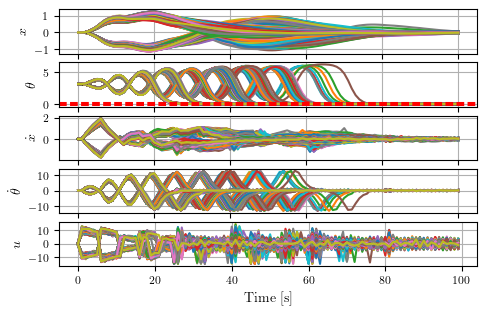

In [4]:
print(np.array(X_all).shape)
t_vec = np.array(t_vec)

# sys.exit()

plt.subplot(5,1,1)
for i in range (0,len(X_all)):
    plt.plot(X_all[i][:,0])
plt.ylabel(r"$x$")
plt.grid(True)
plt.subplot(5,1,2)
for i in range (0,len(X_all)):
    plt.plot(X_all[i][:,1])
# plt.plot(t_vec,x[:,1])
plt.axhline(y=0.2, color='r', linestyle='--')
plt.axhline(y=-0.2, color='r', linestyle='--')
plt.ylabel(r"$\theta$")
plt.grid(True)
plt.subplot(5,1,3)
for i in range (0,len(X_all)):
    plt.plot(X_all[i][:,2])
# plt.plot(t_vec,x[:,2])
plt.ylabel(r"$\dot{x}$")
plt.grid(True)
plt.subplot(5,1,4)
for i in range (0,len(X_all)):
    plt.plot(X_all[i][:,3])
# plt.plot(t_vec,x[:,3])
plt.ylabel(r"$\dot{\theta}$")
plt.grid(True)
plt.subplot(5,1,5)
for i in range (0,len(X_all)):
    plt.plot(U_all[i])
# plt.plot(u_vec)
plt.ylabel(r"$u$")
plt.grid(True)
plt.xlabel("Time [s]")


print(Ksu_all)

In [5]:
np.array(X_all).shape


(1079, 101, 4)

In [8]:
print(len(X_all))
np.array(random.sample(range(0, len(X_all)), k=len(X_all)-100)).shape

1079


(979,)

In [17]:
X_train = []
U_train = []

X_val = []
U_val = []

numbers = random.sample(range(0, len(X_all)), k=len(X_all)-1000)  # get 10 unique random ints from 0 to 185
print(numbers)

for i in range (0,len(X_all)):
    if i in numbers:
        X_val.append(X_all[i])
        U_val.append(U_all[i])
    else:
        X_train.append(X_all[i])
        U_train.append(U_all[i])

## Convert data into hankel matrices 
x1 = np.array([1,2,4])
x2 = np.array([1,2,4])

matrix1 = np.column_stack((x1, x2))
matrix2 = np.vstack((x1, x2))

print(f'X_val[1] = {X_val[1][1,:]}')
print(f'U_val[1] = {U_val[1][1]}')


[220, 628, 195, 306, 186, 143, 382, 18, 1017, 1062, 80, 718, 1068, 1003, 579, 661, 565, 716, 685, 84, 469, 378, 338, 684, 728, 551, 372, 643, 396, 271, 226, 383, 729, 468, 787, 999, 425, 913, 17, 281, 1051, 973, 951, 343, 996, 2, 245, 238, 411, 73, 323, 108, 775, 921, 1031, 602, 434, 819, 891, 553, 992, 248, 305, 10, 230, 259, 454, 769, 835, 899, 365, 785, 114, 896, 1004, 1024, 157, 112, 842]
X_val[1] = [1.75984030e-03 3.14867864e+00 3.51148175e-02 1.36513479e-01]
U_val[1] = 7.693719543522218


In [18]:
X_train = np.array(X_train)
U_train = np.array(U_train)
X_val = np.array(X_val)
U_val = np.array(U_val)

print(X_train.shape)
print(X_val.shape)

(1000, 101, 4)
(79, 101, 4)


In [19]:
B,L,D = X_train.shape
N = 40
X_train = torch.FloatTensor(X_train)
U_train = torch.FloatTensor(U_train)
print(X_train.shape)

X = torch.tensor(())
Y = torch.tensor(())

for i in range(round(B)):
    for j in range(L-N):
        X0 = X_train[i,j,:]
        X0 = torch.FloatTensor([X0[1], torch.cos(X0[1]), torch.sin(X0[1]), X0[2], X0[3]])
        X0 = X0.repeat(N,1).unsqueeze(0)

        UN = U_train[i,j:j+N].unsqueeze(0).unsqueeze(2)

        X = torch.cat((X, torch.cat((UN, X0), 2)), dim=0)

        YN = X_train[i,j+1:j+1+N,:]
        
        YN = torch.cat(([YN[:,0].unsqueeze(0), torch.cos(YN[:,1]).unsqueeze(0), torch.sin(YN[:,1]).unsqueeze(0), YN[:,2].unsqueeze(0), YN[:,3].unsqueeze(0)]), 0).transpose(1,0)
        
        Y = torch.cat((Y, YN.unsqueeze(0)), dim=0)

print(f'X.shape = {X.shape}')
print(f'Y.shape = {Y.shape}')
np.save("X_train.npy", X)
np.save("Y_train.npy", Y)

torch.Size([1000, 101, 4])
X.shape = torch.Size([61000, 40, 6])
Y.shape = torch.Size([61000, 40, 5])


In [20]:
B,L,D = X_val.shape
N = 40
X_val = torch.FloatTensor(X_val)
U_val = torch.FloatTensor(U_val)
print(X_val.shape)

X = torch.tensor(())
Y = torch.tensor(())

for i in range(B):
    for j in range(L-N):
        X0 = X_val[i,j,:]
        X0 = torch.FloatTensor([X0[1], torch.cos(X0[1]), torch.sin(X0[1]), X0[2], X0[3]])
        X0 = X0.repeat(N,1).unsqueeze(0)
        
        UN = U_val[i,j:j+N].unsqueeze(0).unsqueeze(2)

        X = torch.cat((X, torch.cat((UN, X0), 2)), dim=0)
        YN = X_val[i,j+1:j+1+N,:]
        
        YN = torch.cat(([YN[:,0].unsqueeze(0), torch.cos(YN[:,1]).unsqueeze(0), torch.sin(YN[:,1]).unsqueeze(0), YN[:,2].unsqueeze(0), YN[:,3].unsqueeze(0)]), 0).transpose(1,0)
        
        Y = torch.cat((Y, YN.unsqueeze(0)), dim=0)

print(f'X.shape = {X.shape}')
print(f'Y.shape = {Y.shape}')
np.save("X_val.npy", X)
np.save("Y_val.npy", Y)

torch.Size([79, 101, 4])
X.shape = torch.Size([4819, 40, 6])
Y.shape = torch.Size([4819, 40, 5])


In [21]:
646*40

25840

In [22]:
X_val = np.array(X_val)
U_val = np.array(U_val)

X_train = np.array(X_train)
U_train = np.array(U_train)

nx = 5

def Hankel(U_data,X_data,N):
    for k in range(0,len(X_data[:,0,0])):
        print(f'k = {k} / {len(X_data[:,0,0])-1}')
        for j in range(0,len(X_data[0,:,0])-N):
            for i in range(0,N+1):
                if i == 0:
                    Xi = X_data[k,i+j,:]
                    
                    Xi_ext = [X_data[k,i+j,0],np.cos(X_data[k,i+j,1]),np.sin(X_data[k,i+j,1]),X_data[k,i+j,2],X_data[k,i+j,3]]
                    # Xi_ext = np.column_stack(Xi_ext,np.sin(X_data[k,i+j,1]))
                    
                else:
                    Xi_ext_i = [X_data[k,i+j,0],np.cos(X_data[k,i+j,1]),np.sin(X_data[k,i+j,1]),X_data[k,i+j,2],X_data[k,i+j,3]]
                    Xi_ext = np.concatenate((Xi_ext, Xi_ext_i))
                    Xi = np.concatenate((Xi, X_data[k,i+j,:]))
                    # print(f'Xi = {Xi}')
                    # print(f'Xi_ext = {Xi_ext}')
                    # sys.exit()
            if j == 0:
                # Xj = Xi
                Xj = Xi_ext
            else:
                Xj = np.column_stack((Xj, Xi_ext))
        if k == 0:
            Xk = Xj
        else:
            Xk = np.column_stack((Xk, Xj))

    X0 = Xk[0:5,:]
    Y = Xk[5:,:]

    for k in range(0,len(U_data[:,0])):
        print(f'k = {k} / {len(U_data[:,0])-1}')
        for j in range(0,len(U_data[0,:])-N+1):
            for i in range(0,N):
                if i == 0:
                    Ui = U_data[k,i+j]
                else:
                    Ui = np.append(Ui,U_data[k,i+j])
            if j == 0:
                Uj = Ui
            else:
                Uj = np.column_stack((Uj,Ui))
        if k == 0:
            U = Uj
        else:
            U = np.column_stack((U,Uj))
    return U, X0, Y

 

Hu_val, Hx_val, Hy_val  = Hankel(U_val,X_val,N)

Hu_train, Hx_train, Hy_train  = Hankel(U_train,X_train,N)



print(f'Hu_val.shape = {Hu_val.shape}')
print(f'Hx_val.shape = {Hx_val.shape}')
print(f'Hy_val.shape = {Hy_val.shape}')

print(f'Hu_train.shape = {Hu_train.shape}')
print(f'Hx_train.shape = {Hx_train.shape}')
print(f'Hy_train.shape = {Hy_train.shape}')


k = 0 / 645
k = 1 / 645
k = 2 / 645
k = 3 / 645
k = 4 / 645
k = 5 / 645
k = 6 / 645
k = 7 / 645
k = 8 / 645
k = 9 / 645
k = 10 / 645
k = 11 / 645
k = 12 / 645
k = 13 / 645
k = 14 / 645
k = 15 / 645
k = 16 / 645
k = 17 / 645
k = 18 / 645
k = 19 / 645
k = 20 / 645
k = 21 / 645
k = 22 / 645
k = 23 / 645
k = 24 / 645
k = 25 / 645
k = 26 / 645
k = 27 / 645
k = 28 / 645
k = 29 / 645
k = 30 / 645
k = 31 / 645
k = 32 / 645
k = 33 / 645
k = 34 / 645
k = 35 / 645
k = 36 / 645
k = 37 / 645
k = 38 / 645
k = 39 / 645
k = 40 / 645
k = 41 / 645
k = 42 / 645
k = 43 / 645
k = 44 / 645
k = 45 / 645
k = 46 / 645
k = 47 / 645
k = 48 / 645
k = 49 / 645
k = 50 / 645
k = 51 / 645
k = 52 / 645
k = 53 / 645
k = 54 / 645
k = 55 / 645
k = 56 / 645
k = 57 / 645
k = 58 / 645
k = 59 / 645
k = 60 / 645
k = 61 / 645
k = 62 / 645
k = 63 / 645
k = 64 / 645
k = 65 / 645
k = 66 / 645
k = 67 / 645
k = 68 / 645
k = 69 / 645
k = 70 / 645
k = 71 / 645
k = 72 / 645
k = 73 / 645
k = 74 / 645
k = 75 / 645
k = 76 / 645
k = 77 / 

In [14]:
# Example arrays (replace these with yours)

# Put them in a dictionary with variable names
data_to_save = {
    "X_val": X_val,
    "U_val": U_val,
    'Hu_val': Hu_val,
    'Hy_val': Hy_val,
    'Hx_val': Hx_val,
    "X_train": X_train,
    "U_train": U_train,
    'Hu_train': Hu_train,
    'Hy_train': Hy_train,
    'Hx_train': Hx_train
}

# Save to a .mat file
savemat('my_arrays.mat', data_to_save)

print("Arrays saved to 'my_arrays.mat'")


Arrays saved to 'my_arrays.mat'


In [24]:
X_train.shape

(1000, 101, 4)

In [23]:
device = torch.device("cpu:0")

trunk_input_train = torch.tensor(Hx_train, dtype=torch.float32).to(device).T
branch_input_train = torch.tensor(Hu_train, dtype=torch.float32).to(device).T
output_train = torch.squeeze(torch.tensor(Hy_train, dtype=torch.float32).to(device)).T

trunk_input_val = torch.tensor(Hx_val, dtype=torch.float32).to(device).T
branch_input_val = torch.tensor(Hu_val, dtype=torch.float32).to(device).T
output_val = torch.squeeze(torch.tensor(Hy_val, dtype=torch.float32).to(device)).T

B_train = len(trunk_input_train[:,0])
B_val = len(trunk_input_val[:,0])
nx = len(trunk_input_train[0,:])
Nnu = len(branch_input_train[0,:])
Nny = len(output_train[0,:])


# sys.exit()

def train(idx,neuron_b,neuron_t,layer,ld,loss_val_i):
    niter = 2001

    # branch = models.MLP(
    #     layers=[Nnu] + [neuron_b] * layer + [ld*Nny],
    #     activation=F.tanh,
    # ).to(device)

    # trunk = models.MLP(layers=[nx] + [neuron_t] * layer + [ld], activation=F.tanh).to(device)

    branch = models.MLP(
        layers=[Nnu] + [128] + [256] + [128] + [ld*Nny],
        activation=F.tanh,
    ).to(device)

    trunk = models.MLP(layers=[nx] + [128] + [256] + [128] + [ld], activation=F.tanh).to(device)

    # print(trunk)
    # sys.exit()

    # Adding L2 regularization (weight decay) to the optimizer
    optimizer = torch.optim.AdamW(
        list(branch.parameters()) + list(trunk.parameters()), 
        lr=1e-3,
        weight_decay=1e-5  # L2 regularization (weight decay)
    )

    # Add a learning rate scheduler that reduces the learning rate by a factor of 0.1 every 1000 iterations
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.1)

    # training
    train_loss_hist = []
    val_loss_hist = []
    t0 = time.time()
    for i in range(niter):

        def train_step():
            optimizer.zero_grad()            
            b_out = branch(branch_input_train)
            t_out = trunk(trunk_input_train)
            # print(b_out.shape)
            b_out = b_out.reshape(B_train, Nny, ld)
            u_pred = torch.einsum("bij,bj->bi", b_out, t_out)
            # print(branch)
            # print(output_train.shape)
            # sys.exit()
            loss = torch.mean((u_pred - output_train) ** 2) / torch.mean((output_train) ** 2)
            loss.backward()
            optimizer.step()
            return loss
        

        def validation_step():
             with torch.no_grad():               
                b_out = branch(branch_input_val)
                t_out = trunk(trunk_input_val)
                b_out = b_out.reshape(B_val, Nny, ld)
                u_pred = torch.einsum("bij,bj->bi", b_out, t_out)
                # print(u_pred.shape)
                # print(output_val.shape)
                # sys.exit()
                loss = torch.mean((u_pred - output_val) ** 2) / torch.mean((output_val) ** 2)
                return loss

        loss_train = train_step()
        loss_val = validation_step()
        l_train = loss_train.detach().cpu().numpy()
        l_val = loss_val.detach().cpu().numpy()


        train_loss_hist.append(l_train)
        val_loss_hist.append(l_val)

        # Get the current learning rate from the optimizer
        current_lr = optimizer.param_groups[0]['lr']

        # Round the learning rate to 5 decimal places
        current_lr = round(current_lr, 5)
        
        if i % 10 == 0:
            print(
                "index: ",
                idx,
                "/ 8",
                "Epoch: ",
                i + 1,
                "Learning rate: ",
                current_lr,
                "Train loss",
                l_train,
                "Val loss",
                l_val,
                flush=True,
            )
        if i % 1000 == 0 and loss_val_i >= l_val:
            loss_val_i = l_val
            l_indx_i = i
            torch.save(branch, "data_mimo/kan_mlp_branch_idx_{}".format(str(int(idx))))
            torch.save(trunk, "data_mimo/kan_mlp_trunk_idx_{}".format(str(int(idx))))

        # Step the scheduler at the end of each iteration
        scheduler.step()
        
    t1 = time.time()
    print("Total time: ", t1 - t0, flush=True)
    np.save("data_mimo/train_loss.npy", train_loss_hist, allow_pickle=True)
    np.save("data_mimo/val_loss.npy", val_loss_hist, allow_pickle=True)

    torch.save(branch, "data_mimo/mlp_branch_idx_{}".format(str(int(idx))))
    torch.save(trunk, "data_mimo/mlp_trunk_idx_{}".format(str(int(idx))))

    return np.array(train_loss_hist), np.array(val_loss_hist), l_indx_i, loss_val_i


# start of the ablation study 
ablation_results = [] 

ld_list = [ld] # Neurons in output hidden layer 
neuron_b_list = [l_neuron_branch] # Neurons per hidden layer
neuron_t_list = [l_neuron_trunk] # Neurons per hidden layer
layer_list = [l_layer] # [l_layer] # number of hidden layers

# ld_list = [10]
# neuron_list = [20]
# layer_list = [2]


combinations = itertools.product(ld_list,neuron_b_list,neuron_t_list,layer_list)


idx_i = 0

# Looping through the range of indices (1 to idx_total-1 in this case, but you can extend it)
for ld_i, neuron_b_i, neuron_t_i, layer_i in combinations:
    idx_i += 1
    # Call the train function with the current index
    train_loss_hist_i, val_loss_hist_i, l_indx_opt, loss_val_opt   =  train(idx=idx_i,ld=ld_i, neuron_b = neuron_b_i ,neuron_t =neuron_t_i,layer=layer_i,loss_val_i=float('inf'))
    
    # Create a dictionary to store the results
    results = {
        'idx': idx_i,
        'neurons output layer': ld_i,
        'neurons hidden per layer branch': neuron_b_i,
        'neurons hidden per layer trunk': neuron_t_i,
        'hidden layers': layer_i,
        'training loss': train_loss_hist_i,
        'validation loss': val_loss_hist_i
    }
    
    # Append the results to the ablation_results list
    ablation_results.append(results)

# Convert the list of dictionaries into a dictionary of lists
ablation_results_dict = {
    'idx': [entry['idx'] for entry in ablation_results],
    'neurons_output_layer': [entry['neurons output layer'] for entry in ablation_results],
    'neurons_hidden_per_layer_branch': [entry['neurons hidden per layer branch'] for entry in ablation_results],
    'neurons_hidden_per_layer_trunk': [entry['neurons hidden per layer trunk'] for entry in ablation_results],
    'hidden_layers': [entry['hidden layers'] for entry in ablation_results],
}

ablation_results_dict['training_loss'] = np.array([entry['training loss'] for entry in ablation_results])
ablation_results_dict['validation_loss'] = np.array([entry['validation loss'] for entry in ablation_results])

# Save the data as a .mat file
scipy.io.savemat('data_mimo/ablation_results.mat', ablation_results_dict)


# Print the results to verify
print("End main.")
print(ablation_results)
print('result 1:')
print(ablation_results[0]['training loss'])
print('result 2:')
print(ablation_results[0]['training loss'])

l_indx_opt, loss_val_opt
print(f'l_indx_opt: {l_indx_opt}')
print(f'loss_val_opt: {loss_val_opt}')




index:  1 / 8 Epoch:  1 Learning rate:  0.001 Train loss 1.0012703 Val loss 0.98688805
index:  1 / 8 Epoch:  11 Learning rate:  0.001 Train loss 0.60565346 Val loss 0.5527977
index:  1 / 8 Epoch:  21 Learning rate:  0.001 Train loss 0.41913456 Val loss 0.38431004
index:  1 / 8 Epoch:  31 Learning rate:  0.001 Train loss 0.2976135 Val loss 0.267238
index:  1 / 8 Epoch:  41 Learning rate:  0.001 Train loss 0.21263564 Val loss 0.19335212
index:  1 / 8 Epoch:  51 Learning rate:  0.001 Train loss 0.16695774 Val loss 0.15305243
index:  1 / 8 Epoch:  61 Learning rate:  0.001 Train loss 0.13730454 Val loss 0.12823974
index:  1 / 8 Epoch:  71 Learning rate:  0.001 Train loss 0.116540104 Val loss 0.11042552
index:  1 / 8 Epoch:  81 Learning rate:  0.001 Train loss 0.10084005 Val loss 0.09619228
index:  1 / 8 Epoch:  91 Learning rate:  0.001 Train loss 0.08860896 Val loss 0.085346185
index:  1 / 8 Epoch:  101 Learning rate:  0.001 Train loss 0.07970825 Val loss 0.07682951
index:  1 / 8 Epoch:  11

Text(0.5, 1.0, 'Training and validation loss')

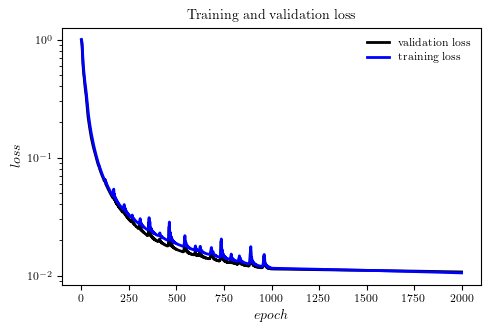

In [24]:
# Load the loss data
val_loss = np.load("data_mimo/val_loss.npy")
train_loss = np.load("data_mimo/train_loss.npy")

####### Row 0: u(t,x) ##################    
gs0 = gridspec.GridSpec(1,1)
#gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
ax = plt.subplot(gs0[:, :])
ax.semilogy(val_loss, '-k', lw=2.0, label="validation loss")
ax.semilogy(train_loss, '-b', lw=2.0, label="training loss")
ax.set_xlabel('$epoch$')
ax.set_ylabel('$loss$')
ax.legend(frameon=False, loc = 'best')
ax.set_title('Training and validation loss', fontsize = 10)

trunk_input_val[0,:] = tensor([ 0.0870,  0.1430,  0.9897,  0.6263, -7.1809])
branch_input_val[0,:] = tensor([ 0.8463,  0.2862, -0.1503, -1.1365, -1.9395,  0.2782, -0.7898,  0.3177,
        -2.8169, -2.1710, -2.3766, -0.9581, -1.3670, -3.4093, -3.3185, -3.3256,
        -0.7602, -1.0966, -1.3614, -1.1952, -8.9602,  4.6867, -1.0784,  5.2678,
        -2.9084,  2.9720, -0.8630,  1.7966,  1.2050,  1.8043, -0.6456,  1.3229,
         1.1987, -0.7882,  1.6438,  0.0487,  0.8820, -0.1071, -0.3467,  1.4543])
torch.Size([200, 40])
torch.Size([40])
Yhat_val = tensor([ 1.7507e-01,  4.8962e-01,  7.0907e-01,  7.2488e-01, -3.3115e+00,
         1.6982e-01,  8.2143e-01,  5.9022e-01,  7.8433e-01, -5.4163e-01,
         2.8044e-01,  7.2052e-01,  7.5399e-01,  6.5589e-01,  1.9694e+00,
         3.3895e-01,  3.3220e-01,  9.6048e-01,  6.4321e-01,  5.4651e+00,
         3.6715e-01, -4.9323e-01,  8.6704e-01,  6.4736e-01,  9.9714e+00,
         4.3208e-01, -8.7407e-01, -2.1752e-02,  8.0565e-01,  1.1552e+01,
         5

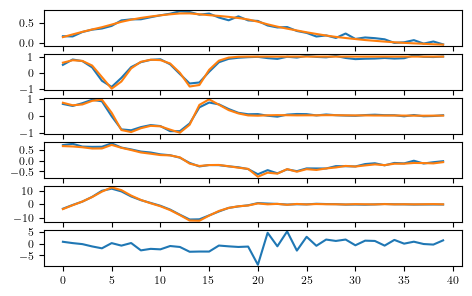

In [25]:
branch = torch.load("data_mimo/kan_mlp_branch_idx_1", weights_only=False)
trunk = torch.load("data_mimo/kan_mlp_trunk_idx_1", weights_only=False)


Index = 40

trunk_input_val = torch.tensor(Hx_val, dtype=torch.float32).to(device).T
branch_input_val = torch.tensor(Hu_val, dtype=torch.float32).to(device).T
output_val = torch.squeeze(torch.tensor(Hy_val, dtype=torch.float32).to(device)).T


print(f'trunk_input_val[0,:] = {trunk_input_val[Index,:]}')
print(f'branch_input_val[0,:] = {branch_input_val[Index,:]}')
# print(f'output_val[0,:] = {output_val[0,:]}')

b_out = branch(branch_input_val[Index,:])
t_out = trunk(trunk_input_val[Index,:])
b_out = b_out.reshape(Nny, ld)


print(b_out.shape)
print(t_out.shape)

Yhat_val = torch.einsum("bj,j->b", b_out, t_out)

print(f'Yhat_val = {Yhat_val}')
print(f'Yhat_val = {Yhat_val[0::5]}')
print(f'Yhat_val = {Yhat_val[1::5]}')

y1 = Yhat_val[0::5]
y2 = Yhat_val[1::5]
y3 = Yhat_val[2::5]
y4 = Yhat_val[3::5]
y5 = Yhat_val[4::5]

plt.figure()
plt.subplot(6,1,1)
plt.plot(y1.detach().cpu().numpy())
plt.plot(output_val[Index,0::5])
plt.subplot(6,1,2)
plt.plot(y2.detach().cpu().numpy())
plt.plot(output_val[Index,1::5])
plt.subplot(6,1,3)
plt.plot(y3.detach().cpu().numpy())
plt.plot(output_val[Index,2::5])
plt.subplot(6,1,4)
plt.plot(y4.detach().cpu().numpy())
plt.plot(output_val[Index,3::5])
plt.subplot(6,1,5)
plt.plot(y5.detach().cpu().numpy())
plt.plot(output_val[Index,4::5])
plt.subplot(6,1,6)
plt.plot(branch_input_val[Index,:].detach().cpu().numpy())
# print()

In [42]:
# print(branch)
# print(trunk)

# torch.save(branch, "data_mimo/kan_mlp_branch_2_working")
# torch.save(trunk, "data_mimo/kan_mlp_trunk_2_working")

Q = [[   1    0    0 ...    0    0    0]
 [   0 1000    0 ...    0    0    0]
 [   0    0    1 ...    0    0    0]
 ...
 [   0    0    0 ...    1    0    0]
 [   0    0    0 ...    0    1    0]
 [   0    0    0 ...    0    0    1]]
y.shape = (200, 1)
u.shape = (40, 1)
R = [[0.01 0.   0.   ... 0.   0.   0.  ]
 [0.   0.01 0.   ... 0.   0.   0.  ]
 [0.   0.   0.01 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.01 0.   0.  ]
 [0.   0.   0.   ... 0.   0.01 0.  ]
 [0.   0.   0.   ... 0.   0.   0.01]]
(40, 1)
(40, 200)
i = 0 / 100
x_current_ext =  [ 0.5 -1.   0.   0.   0. ]
u_mpc =  0
i = 1 / 100
x_current_ext =  [ 0.50331499 -0.99991092 -0.01334723  0.06614513  0.25714436]
u_mpc =  1.6331685811678254
i = 2 / 100
x_current_ext =  [ 0.4962356  -0.99979141  0.02042413 -0.20734038 -0.90780016]
u_mpc =  -6.71046994414168
i = 3 / 100
x_current_ext =  [ 0.47046374 -0.99264426  0.12106762 -0.30689298 -1.03641515]
u_mpc =  -2.568064376448713
i = 4 / 100
x_current_ext =  [ 0.44468388 -0.98478293  0.1

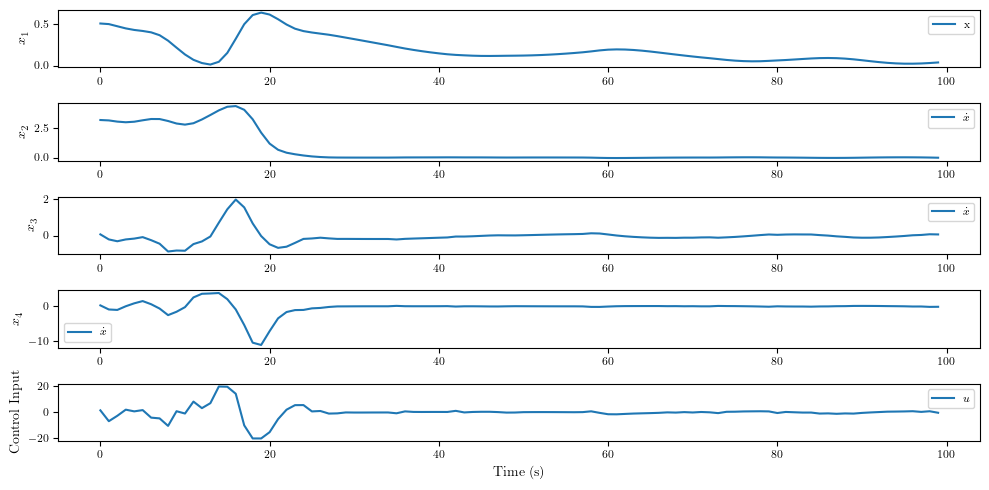

In [27]:
def NN(u, Network, sigma):
    """Evaluate the neural network with input u."""
    y = u
    L = len(Network.linears)
    for i in range(L - 1):
        W = ca.DM(Network.linears[i].weight.detach().cpu().numpy())
        b = ca.DM(Network.linears[i].bias.detach().cpu().numpy())
        y = sigma(W @ y + b)  # @ is matrix multiplication
    
    W = ca.DM(Network.linears[-1].weight.detach().cpu().numpy())
    b = ca.DM(Network.linears[-1].bias.detach().cpu().numpy())
    y = W @ y + b
    return y

# torch.serialization.add_safe_globals([models.MLP])

# branch = torch.load("data_mimo/kan_mlp_branch_working")
# trunk = torch.load("data_mimo/kan_mlp_trunk_idx_working")

branch = torch.load("data_mimo/kan_mlp_branch_idx_1", weights_only=False)
trunk = torch.load("data_mimo/kan_mlp_trunk_idx_1", weights_only=False)


# Pendulum parameters

nx = 5  # [theta, theta_dot]
ny = 5  # [theta, theta_dot]
nu = 1  # torque
N = 40
Nny = N*ny

Ref = np.tile([0, 1, 0, 0, 0], N)

opti = ca.Opti()
y = opti.variable(ny*N,)
u = opti.variable(nu*N,)
du = opti.variable(nu*N,)
x0 = opti.parameter(nx)
u0 = opti.parameter(nu)
# ref = opti.parameter(ny*N,)


# Q = np.diag(np.tile([1, 10000, 0, 10, 10], N))
# R = 0.01*np.eye(N * nu)

Q = np.diag(np.tile([1, 1000, 1, 1, 1], N))
R = 0.01*np.eye(N * nu)

print(f'Q = {Q}')
print(f'y.shape = {y.shape}')
print(f'u.shape = {u.shape}')

print(f'R = {R}')
# sys.exit()

cost = ca.mtimes([(y-Ref).T, Q, (y-Ref)]) + ca.mtimes([u.T, R, u])

# Neural network predictions
b_out = NN(u, branch, np.tanh)
t_out = NN(x0, trunk, np.tanh)
b_out = ca.reshape(b_out, ld,Nny)

print(t_out.shape)
print(b_out.shape)
# sys.exit()
opti.subject_to(y == b_out.T@t_out)
# opti.subject_to(du[0:nu] == u[0:nu] - u0)
# opti.subject_to(du[nu:] == u[nu:] - u[:-nu])

opti.subject_to(opti.bounded(-20.0, u, 20.0))

# opti.subject_to(opti.bounded(-1.0, U, 1.0))  # torque bounds
opti.minimize(cost)

# Solver options
opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0})

# Simulation
# sim_time = 500
# steps = int(sim_time / dt)

x_vals = []
u_vals = []
x_current = np.array([0.5, np.pi, 0.0 ,0.0])  # 90 degrees
x_current_ext = np.array([0.5, -1.0, 0.0 ,0.0, 0.0])  # 90 degrees

u_mpc = 0
solve_times = []  # Initialize empty list to store solve times

for i in range(100):
    print(f'i = {i} / {100}')
    print(f'x_current_ext =  {x_current_ext}')
    print(f'u_mpc =  {u_mpc}')
    
    start = time.perf_counter()
    opti.set_value(x0, x_current_ext)
    sol = opti.solve()
    elapsed = time.perf_counter() - start
    solve_times.append(elapsed)  # Store each solve time
    
    u_mpc = sol.value(u[0])
    
    sol = sol = solve_ivp(lambda t, y: penulum_cart(t, y, u=u_mpc),[0, Ts], x_current, method='RK45')

    x_next = sol.y[:, -1]
    x_current = x_next
    x_current_ext = np.array([x_next[0], np.cos(x_next[1]), np.sin(x_next[1]) ,x_next[2], x_next[3]])  # 90 degrees


    x_vals.append(x_next)
    u_vals.append(u_mpc)

x_vals = np.array(x_vals)
u_vals = np.array(u_vals)

print(f'x_vals.shape = {x_vals.shape}')
print(f'u_vals.shape = {u_vals.shape}')

plt.figure(figsize=(10, 5))
plt.subplot(5, 1, 1)
plt.plot(x_vals[:, 0], label='x')
plt.ylabel("$x_1$")
plt.legend()

plt.subplot(5, 1, 2)
plt.plot(x_vals[:, 1], label='$\dot{x}$')
plt.ylabel("$x_2$")
plt.legend()

plt.subplot(5, 1, 3)
plt.plot(x_vals[:, 2], label='$\dot{x}$')
plt.ylabel("$x_3$")
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(x_vals[:, 3], label='$\dot{x}$')
plt.ylabel("$x_4$")
plt.legend()

plt.subplot(5, 1, 5)
plt.plot( u_vals, label='$u$')
plt.xlabel("Time (s)")
plt.ylabel("Control Input")
plt.legend()

plt.tight_layout()


plt.show()


In [47]:
# Put them in a dictionary with variable names
data_to_save = {
    "x_vals": x_vals,
    "u_vals": u_vals,
    "U_all": U_all,
    "X_all": X_all,
    "val_loss": val_loss,
    "train_loss": train_loss
    
}

# Save to a .mat file
savemat('matlab_results_working_3.mat', data_to_save)

print("Arrays saved to 'matlab_results_working_3.mat'")


Arrays saved to 'matlab_results_working_3.mat'


In [15]:
# Put them in a dictionary with variable names
data_to_save = {
    "x_vals_5": x_vals,
    "u_vals_5": u_vals,   
    "solve_times_5": solve_times, 
}

# Save to a .mat file
savemat('plot_data_5.mat', data_to_save)

print("Arrays saved to 'plot_data_5.mat'")


Arrays saved to 'plot_data_5.mat'
